# AdamW vs Muon: analysis

Reads `ckpt/<run>/logs.json` and the saved checkpoints written by the training notebook. Main setting first (AdamW 2e-5 vs Muon 1e-3, 3 seeds), then the ablations.

In [7]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import gc

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
base = 'ckpt'

runs = sorted(os.listdir(base))
logs = {r: json.load(open(base + '/%s/logs.json' % r)) for r in runs}
print(len(runs), 'runs')


17 runs


## Helpers (For metrics and Plots)

In [2]:
def label(r):
    L = logs[r]
    s = 'AdamW %g' % L['lr_adamw'] if L['optimizer'] == 'adamw' else 'Muon %g' % L['lr_muon']
    if L['optimizer'] == 'muon' and L['momentum'] != 0.95: s += ' mom%g' % L['momentum']
    if L['wd'] != 0: s += ' wd%g' % L['wd']
    return s

def color(r):
    return 'C0' if logs[r]['optimizer'] == 'adamw' else 'C1'

def running_mean(x, k=50):
    c = np.cumsum(np.insert(np.asarray(x), 0, 0))
    return (c[k:] - c[:-k]) / k

def steps(r):
    return sorted(int(f[5:9]) for f in os.listdir(base + '/' + r) if f.endswith('.pt'))

def load_w(r, step):
    sd = torch.load(base + '/%s/step_%04d.pt' % (r, step), map_location='cpu')
    return {n: p for n, p in sd.items() if p.ndim == 2 and 'layers.' in n}     # the 210 block matrices

def block(n):
    return int(n.split('.')[2])

def eff_rank(M, energy=0.99):
    s2 = torch.linalg.svdvals(M.float()) ** 2
    return int((torch.cumsum(s2, 0) / s2.sum() < energy).sum()) + 1

def stable_rank(M):
    s2 = torch.linalg.svdvals(M.float()) ** 2
    return (s2.sum() / s2[0]).item()


## Weight-space metrics (from checkpoints)

- drift per block: $\|W-W_0\|/\|W_0\|$ at the end
- rank of $W-W_0$ per block
- one-step update at step 500: $\|\Delta W\|/\|W\|$ per block, and its stable rank

In [3]:
def drift_per_block(r):
    w0, w = load_w(r, 0), load_w(r, steps(r)[-1])
    num, den = np.zeros(30), np.zeros(30)
    for n in w:
        num[block(n)] += ((w[n] - w0[n]) ** 2).sum().item()
        den[block(n)] += (w0[n] ** 2).sum().item()
    return np.sqrt(num / den)

def rank_per_block(r):
    w0, w = load_w(r, 0), load_w(r, steps(r)[-1])
    rk = [[] for _ in range(30)]
    for n in w:
        rk[block(n)].append(eff_rank(w[n] - w0[n]))
    return np.array([np.mean(x) for x in rk])

def one_step(r, step=500):
    wa, wb = load_w(r, step), load_w(r, step + 1)
    u2, w2, sr = np.zeros(30), np.zeros(30), []
    for n in wa:
        d = wb[n] - wa[n]
        u2[block(n)] += (d ** 2).sum().item()
        w2[block(n)] += (wa[n] ** 2).sum().item()
        sr.append(stable_rank(d))
    return np.sqrt(u2 / w2), np.mean(sr)


## Sharpness (from checkpoints)

$\lambda_{\max}$ of the Hessian by power iteration with Hessian-vector products (checked against finite differences), and the loss increase for an uphill step of size $\rho$ along the gradient. Two fixed training batches for every run.

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from torch.utils.data import DataLoader
from torch.autograd import grad

name = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
dataset = load_dataset("stanfordnlp/sst2")
tokenized = dataset.map(lambda b: tokenizer(b["sentence"], truncation=True, max_length=80), batched=True)
tokenized = tokenized.remove_columns(["sentence", "idx"]).rename_column("label", "labels")
tokenized.set_format("torch")
collator = DataCollatorWithPadding(tokenizer)

g = torch.Generator().manual_seed(0)
loader = DataLoader(tokenized["train"], batch_size=64, shuffle=True, collate_fn=collator, generator=g)
it = iter(loader)
probes = [next(it).to(device) for _ in range(2)]

model = AutoModelForSequenceClassification.from_pretrained(name, num_labels=2, pad_token_id=tokenizer.pad_token_id, dtype=torch.float32).to(device)
model.eval()
params = list(model.parameters())


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3109.75it/s]
[transformers] LlamaForSequenceClassification LOAD REPORT from: HuggingFaceTB/SmolLM2-135M
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
def vnorm(v):
    return torch.sqrt(sum((x ** 2).sum() for x in v)).item()

def loss_on(batches):
    with torch.no_grad():
        return np.mean([model(**b).loss.item() for b in batches])

def add_(v, s):
    with torch.no_grad():
        for p, x in zip(params, v):
            p.add_(x, alpha=s)

def hvp(batches, v):
    Hv = [torch.zeros_like(p) for p in params]
    for b in batches:
        gb = grad(model(**b).loss, params, create_graph=True)
        gv = sum((gi * vi).sum() for gi, vi in zip(gb, v))
        for h, hb in zip(Hv, grad(gv, params)):
            h += hb.detach() / len(batches)
        del gb, gv
        if device == 'mps':
            torch.mps.empty_cache()
    return Hv

def lambda_max(batches, iters=15):
    gen = torch.Generator().manual_seed(0)
    v = [torch.randn(p.shape, generator=gen).to(device) for p in params]
    n = vnorm(v); v = [x / n for x in v]
    lam = None
    for _ in range(iters):
        Hv = hvp(batches, v)
        lam_new = sum((h * vi).sum() for h, vi in zip(Hv, v)).item()
        n = vnorm(Hv); v = [h / n for h in Hv]
        if lam is not None and abs(lam_new - lam) < 1e-3 * abs(lam_new):
            return lam_new
        lam = lam_new
    return lam

def uphill(batches, rho=0.05):
    base_loss = loss_on(batches)
    g = [torch.zeros_like(p) for p in params]
    for b in batches:
        for gi, gbi in zip(g, grad(model(**b).loss, params)):
            gi += gbi / len(batches)
    n = vnorm(g)
    add_(g, rho / n); up = loss_on(batches); add_(g, -rho / n)
    return up - base_loss

def sharpness(r, step):
    model.load_state_dict(torch.load(base + '/%s/step_%04d.pt' % (r, step), map_location=device))
    return dict(loss=loss_on(probes), lambda_max=lambda_max(probes), uphill=uphill(probes))


## Compute everything once (cached in stats.json)

In [8]:
stats = json.load(open('stats.json')) if os.path.exists('stats.json') else {}

for r in runs:
    if r in stats:
        continue
    upd, sr = one_step(r)
    drift, rank = drift_per_block(r), rank_per_block(r)
    gc.collect()
    s = sharpness(r, steps(r)[-1])
    stats[r] = dict(drift=drift_per_block(r).tolist(), rank=rank_per_block(r).tolist(),
                    rel_update=upd.tolist(), step_stable_rank=sr, **s)
    json.dump(stats, open('stats.json', 'w'))
    print('%-22s drift %.4f  rank %.0f  srank %.1f  lam %.1f  uphill %.3f' % (label(r), np.mean(stats[r]['drift']), np.mean(stats[r]['rank']), sr, s['lambda_max'], s['uphill']))


AdamW 1e-05            drift 0.0024  rank 244  srank 3.5  lam 347.1  uphill 0.154
AdamW 2e-05 wd0.01     drift 0.0035  rank 271  srank 3.4  lam 248.8  uphill 0.111
AdamW 2e-05            drift 0.0035  rank 264  srank 3.4  lam 249.0  uphill 0.110
AdamW 2e-05            drift 0.0035  rank 264  srank 3.7  lam 230.0  uphill 0.262
AdamW 2e-05            drift 0.0035  rank 265  srank 4.4  lam 278.7  uphill 0.084
AdamW 5e-05            drift 0.0069  rank 286  srank 4.4  lam 172.7  uphill 0.240
AdamW 5e-05            drift 0.0069  rank 284  srank 3.9  lam 183.3  uphill 0.100
Muon 0.0003            drift 0.0107  rank 386  srank 215.1  lam 193.8  uphill 0.058
Muon 0.0003            drift 0.0106  rank 384  srank 216.7  lam 179.6  uphill 0.067
Muon 0.001 wd0.01      drift 0.0353  rank 400  srank 201.5  lam 175.4  uphill 0.193
Muon 0.001             drift 0.0337  rank 387  srank 206.4  lam 165.3  uphill 0.109
Muon 0.001             drift 0.0334  rank 385  srank 212.5  lam 135.3  uphill 0.070
Muon 0

## Main setting: AdamW 2e-5 vs Muon 1e-3, 3 seeds

In [9]:
def pick(opt, lrA=2e-5, lrM=1e-3, mom=0.95, wd=0.0):
    return [r for r in runs if logs[r]['optimizer'] == opt and logs[r]['lr_adamw'] == lrA and logs[r]['lr_muon'] == lrM
            and logs[r]['momentum'] == mom and logs[r]['wd'] == wd]

adam = pick('adamw')
muon = pick('muon')

def mean_curve(rs, key):
    return np.mean([running_mean(logs[r][key]) for r in rs], axis=0)

def val(rs, col):          # col 1 = val loss, 2 = val acc
    v = np.array([np.array(logs[r]['val_log'])[:, col] for r in rs])
    return np.array(logs[rs[0]]['val_log'])[:, 0], v.mean(0)

def summary(rs):
    best  = [max(x[2] for x in logs[r]['val_log']) for r in rs]
    final = [logs[r]['val_log'][-1][2] for r in rs]
    vloss = [logs[r]['val_log'][-1][1] for r in rs]
    drift = [np.mean(stats[r]['drift']) for r in rs]
    lam   = [stats[r]['lambda_max'] for r in rs]
    return best, final, vloss, drift, lam

for name_, rs in [('AdamW 2e-5', adam), ('Muon 1e-3', muon)]:
    best, final, vloss, drift, lam = summary(rs)
    print('%-12s n=%d  best acc %.3f±%.3f  final acc %.3f±%.3f  val loss %.3f  drift %.4f  lam %.0f±%.0f' % (
        name_, len(rs), np.mean(best), np.std(best), np.mean(final), np.std(final), np.mean(vloss), np.mean(drift), np.mean(lam), np.std(lam)))


AdamW 2e-5   n=3  best acc 0.935±0.002  final acc 0.929±0.002  val loss 0.204  drift 0.0035  lam 253±20
Muon 1e-3    n=3  best acc 0.930±0.005  final acc 0.920±0.004  val loss 0.205  drift 0.0337  lam 172±33


## Figure 1 (report)

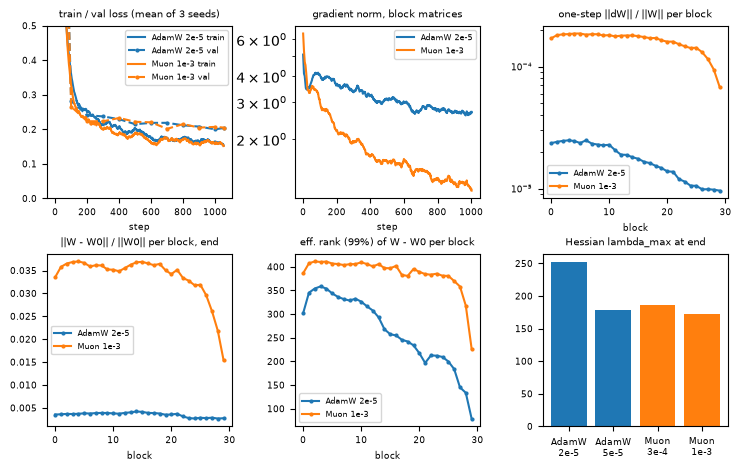

In [10]:
a1, m1 = adam[0], muon[0]      # seed-1 runs for the per-block panels
fig, ax = plt.subplots(2, 3, figsize=(7.3, 4.6))

for rs, lab, c in [(adam, 'AdamW 2e-5', 'C0'), (muon, 'Muon 1e-3', 'C1')]:
    ax[0, 0].plot(np.arange(50, 1053 + 1), mean_curve(rs, 'train_loss'), color=c, label=lab + ' train')
    ax[0, 0].plot(*val(rs, 1), color=c, ls='--', marker='o', ms=2, label=lab + ' val')
    ax[0, 1].plot(mean_curve(rs, 'grad_norm_muon'), color=c, label=lab)
ax[0, 0].set_title('train / val loss (mean of 3 seeds)'); ax[0, 0].set_ylim(0, 0.5); ax[0, 0].set_xlabel('step')
ax[0, 1].set_yscale('log'); ax[0, 1].set_title('gradient norm, block matrices'); ax[0, 1].set_xlabel('step')

for r, lab, c in [(a1, 'AdamW 2e-5', 'C0'), (m1, 'Muon 1e-3', 'C1')]:
    ax[0, 2].plot(stats[r]['rel_update'], color=c, marker='o', ms=2, label=lab)
    ax[1, 0].plot(stats[r]['drift'], color=c, marker='o', ms=2, label=lab)
    ax[1, 1].plot(stats[r]['rank'], color=c, marker='o', ms=2, label=lab)
ax[0, 2].set_yscale('log'); ax[0, 2].set_title('one-step ||dW|| / ||W|| per block'); ax[0, 2].set_xlabel('block')
ax[1, 0].set_title('||W - W0|| / ||W0|| per block, end'); ax[1, 0].set_xlabel('block')
ax[1, 1].set_title('eff. rank (99%) of W - W0 per block'); ax[1, 1].set_xlabel('block')

bars = [('AdamW\n2e-5', adam), ('AdamW\n5e-5', pick('adamw', lrA=5e-5)), ('Muon\n3e-4', pick('muon', lrM=3e-4)), ('Muon\n1e-3', muon)]
ax[1, 2].bar([b[0] for b in bars], [np.mean([stats[r]['lambda_max'] for r in b[1]]) for b in bars], color=['C0', 'C0', 'C1', 'C1'])
ax[1, 2].set_title('Hessian lambda_max at end')

for a in ax.flat:
    a.tick_params(labelsize=6.5); a.title.set_fontsize(7.5); a.xaxis.label.set_fontsize(6.5)
    if a.get_legend_handles_labels()[0]:
        a.legend(fontsize=6)
plt.tight_layout(pad=0.3)
plt.savefig('fig1.png', dpi=300)
plt.show()


## Additional results: all configs

In [11]:
groups = {}
for r in runs:
    groups.setdefault(label(r), []).append(r)

print('%-22s %2s %12s %12s %8s %8s %10s %8s' % ('config', 'n', 'best acc', 'final acc', 'val loss', 'drift', 'lam_max', 'srank1'))
for c, rs in groups.items():
    best, final, vloss, drift, lam = summary(rs)
    sr = np.mean([stats[r]['step_stable_rank'] for r in rs])
    print('%-22s %2d  %.3f±%.3f  %.3f±%.3f  %8.3f %8.4f %5.0f±%-4.0f %8.1f' % (
        c, len(rs), np.mean(best), np.std(best), np.mean(final), np.std(final), np.mean(vloss), np.mean(drift), np.mean(lam), np.std(lam), sr))


config                  n     best acc    final acc val loss    drift    lam_max   srank1
AdamW 1e-05             1  0.923±0.000  0.921±0.000     0.225   0.0024   347±0         3.5
AdamW 2e-05 wd0.01      1  0.937±0.000  0.929±0.000     0.204   0.0035   249±0         3.4
AdamW 2e-05             3  0.935±0.002  0.929±0.002     0.204   0.0035   253±20        3.8
AdamW 5e-05             2  0.935±0.006  0.929±0.005     0.191   0.0069   178±5         4.2
Muon 0.0003             2  0.932±0.002  0.931±0.004     0.200   0.0107   187±7       215.9
Muon 0.001 wd0.01       1  0.936±0.000  0.925±0.000     0.195   0.0353   175±0       201.5
Muon 0.001              3  0.930±0.005  0.920±0.004     0.205   0.0337   172±33      215.1
Muon 0.001 mom0.9       1  0.933±0.000  0.919±0.000     0.195   0.0246   208±0       183.7
Muon 0.001 mom0         1  0.919±0.000  0.916±0.000     0.337   0.0081   283±0        71.5
Muon 0.003              2  0.909±0.000  0.890±0.003     0.269   0.0978   134±39      201.4


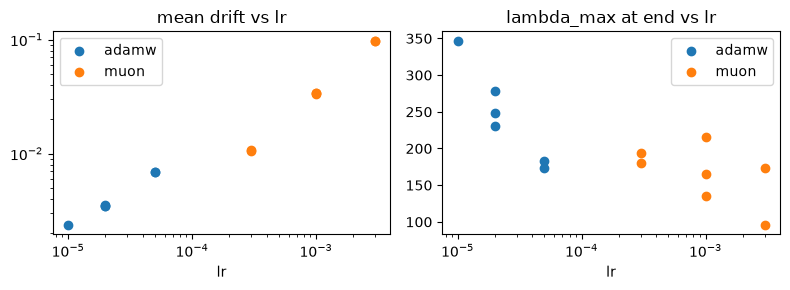

In [12]:
# learning-rate sweep: drift and sharpness vs lr
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for opt, key, c in [('adamw', 'lr_adamw', 'C0'), ('muon', 'lr_muon', 'C1')]:
    rs = [r for r in runs if logs[r]['optimizer'] == opt and logs[r]['momentum'] == 0.95 and logs[r]['wd'] == 0]
    lrs = [logs[r][key] for r in rs]
    ax[0].scatter(lrs, [np.mean(stats[r]['drift']) for r in rs], color=c, label=opt)
    ax[1].scatter(lrs, [stats[r]['lambda_max'] for r in rs], color=c, label=opt)
ax[0].set_title('mean drift vs lr'); ax[1].set_title('lambda_max at end vs lr')
for a in ax: a.set_xscale('log'); a.set_xlabel('lr'); a.legend()
ax[0].set_yscale('log')
plt.tight_layout(); plt.savefig('supp_lr.png', dpi=200); plt.show()


In [13]:
# momentum ablation
rs = sorted(pick('muon', mom=0.0) + pick('muon', mom=0.9) + muon[:1], key=lambda r: logs[r]['momentum'])
print('%-22s %8s %8s %8s %8s %8s' % ('run', 'best acc', 'val loss', 'drift', 'srank1', 'lam'))
for r in rs:
    print('%-22s %8.4f %8.4f %8.4f %8.1f %8.1f' % (label(r), max(x[2] for x in logs[r]['val_log']), logs[r]['val_log'][-1][1],
                                                 np.mean(stats[r]['drift']), stats[r]['step_stable_rank'], stats[r]['lambda_max']))


run                    best acc val loss    drift   srank1      lam
Muon 0.001 mom0          0.9186   0.3366   0.0081     71.5    282.8
Muon 0.001 mom0.9        0.9335   0.1951   0.0246    183.7    207.8
Muon 0.001               0.9346   0.1939   0.0337    206.4    165.3


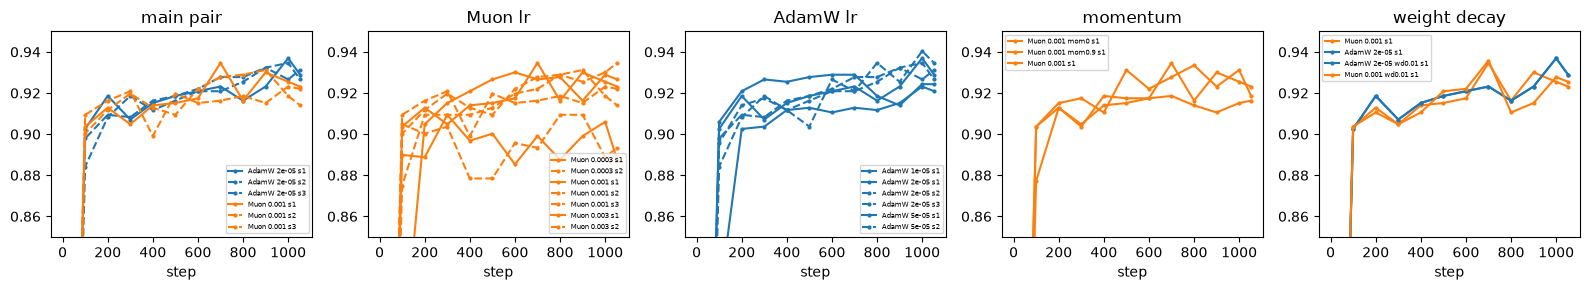

In [14]:
# val acc for every run, one panel per comparison
comps = {
    'main pair': adam + muon,
    'Muon lr':  [r for r in runs if logs[r]['optimizer'] == 'muon' and logs[r]['momentum'] == 0.95 and logs[r]['wd'] == 0],
    'AdamW lr': [r for r in runs if logs[r]['optimizer'] == 'adamw' and logs[r]['wd'] == 0],
    'momentum': rs,
    'weight decay': muon[:1] + adam[:1] + pick('adamw', wd=0.01) + pick('muon', wd=0.01),
}
fig, ax = plt.subplots(1, 5, figsize=(16, 3))
for a, (k, rr) in zip(ax, comps.items()):
    for r in rr:
        v = np.array(logs[r]['val_log'])
        a.plot(v[:, 0], v[:, 2], color=color(r), ls='-' if logs[r]['seed'] == 1 else '--', marker='o', ms=2, label='%s s%d' % (label(r), logs[r]['seed']))
    a.set_title(k); a.set_ylim(0.85, 0.95); a.set_xlabel('step'); a.legend(fontsize=5)
plt.tight_layout(); plt.savefig('supp_valacc.png', dpi=200); plt.show()
